<a href="https://colab.research.google.com/github/AnthonyMath1022/AnthonyMath1022/blob/main/Retail_Analysis_VAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd
import numpy as np
from IPython.display import display
from google.colab import drive
drive.mount('/content/drive')
%load_ext cudf.pandas
print('Loading data...')
train_path = '/content/drive/MyDrive/Reatilforecast/src/train.csv'
train_df = pd.read_csv(train_path, low_memory=True)
train_df['date'] = pd.to_datetime(train_df['date'])
pd.set_option('display.max_columns', 10)
display(train_df)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
The cudf.pandas extension is already loaded. To reload it, use:
  %reload_ext cudf.pandas
Loading data...


,id,date,store_nbr,item_nbr,unit_sales,onpromotion
0,0,2013-01-01,25,103665,7.0,NaN
1,1,2013-01-01,25,105574,1.0,NaN
2,2,2013-01-01,25,105575,2.0,NaN
3,3,2013-01-01,25,108079,1.0,NaN
4,4,2013-01-01,25,108701,1.0,NaN
...,...,...,...,...,...,...
125497035,125497035,2017-08-15,54,2089339,4.0,False
125497036,125497036,2017-08-15,54,2106464,1.0,True
125497037,125497037,2017-08-15,54,2110456,192.0,False
125497038,125497038,2017-08-15,54,2113914,198.0,True


In [19]:
start_date = '2017-07-01'
end_date = '2017-12-31'

train_df = train_df[(train_df['date'] >= start_date) & (train_df['date'] <= end_date)]
pd.set_option('display.max_columns', 10)
display(train_df)
train_df.count()
train_df.isna().sum()


,id,date,store_nbr,item_nbr,unit_sales,onpromotion
120642911,120642911,2017-07-01,1,99197,2.0,False
120642912,120642912,2017-07-01,1,103520,2.0,False
120642913,120642913,2017-07-01,1,103665,11.0,False
120642914,120642914,2017-07-01,1,105574,2.0,False
120642915,120642915,2017-07-01,1,105575,3.0,False
...,...,...,...,...,...,...
125497035,125497035,2017-08-15,54,2089339,4.0,False
125497036,125497036,2017-08-15,54,2106464,1.0,True
125497037,125497037,2017-08-15,54,2110456,192.0,False
125497038,125497038,2017-08-15,54,2113914,198.0,True


id             0
date           0
store_nbr      0
item_nbr       0
unit_sales     0
onpromotion    0
dtype: int64

In [20]:
import pandas as pd

item_path = '/content/drive/MyDrive/Reatilforecast/src/items.csv'
store_path = '/content/drive/MyDrive/Reatilforecast/src/stores.csv'
oil_path = '/content/drive/MyDrive/Reatilforecast/src/oil.csv'

item = pd.read_csv(item_path)
store = pd.read_csv(store_path)
oil = pd.read_csv(oil_path )
oil = oil[(oil['date'] >= start_date) & (oil['date'] <= end_date)]

train_df = pd.merge(train_df,item,on='item_nbr',how='left')
train_df = pd.merge(train_df,store,on='store_nbr',how='left')
train_df.isna().sum()

id             0
date           0
store_nbr      0
item_nbr       0
unit_sales     0
onpromotion    0
family         0
class          0
perishable     0
city           0
state          0
type           0
cluster        0
dtype: int64

In [21]:
import numpy as np

def most_frequent_sales(data, variable, N, all='TRUE'):


    # counts
    values, counts = np.unique(data[variable].to_numpy(), return_counts=True)

    # Ensure values and counts are 2D column vectors before stacking
    values_2d = values.reshape(-1, 1)
    counts_2d = counts.reshape(-1, 1)

    # Nx2 table: [value, count]
    labels_freq_pd = np.column_stack((values_2d, counts_2d))

    # sort by count desc
    labels_freq_pd = labels_freq_pd[np.argsort(labels_freq_pd[:, 1])[::-1]]

    # keep top N
    topN = labels_freq_pd[:N]
    main_labels = topN[:, 0] if all == 'False' else labels_freq_pd[:, 0]

    # raw labels (replace deprecated as_matrix)
    labels_raw_np = data[variable].to_numpy().reshape(-1, 1)

    # indices where label in main_labels (same style as your labels_filtered_index[0])
    labels_filtered_index = np.where(np.isin(labels_raw_np.ravel(), main_labels))

    return topN, labels_filtered_index

label_freq, labels_filtered_index = most_frequent_sales(train_df, 'item_nbr', 5, 'FALSE')
print("pd_train.shape=", labels_filtered_index[0].shape)

pd_train_filtered = train_df.loc[labels_filtered_index[0], :]
print("pd_train_filtered.shape = ", pd_train_filtered.shape)


pd_train.shape= (4854129,)
pd_train_filtered.shape =  (4854129, 13)


In [22]:
pd_train_filtered  = pd_train_filtered.drop(['city','state','type','cluster','store_nbr','item_nbr','family','class','id'], axis = 1)

In [23]:

dummy_variables = ['onpromotion','perishable']

for var in dummy_variables:
    dummy = pd.get_dummies(pd_train_filtered [var], prefix = var, drop_first = False).astype(int)
    pd_train_filtered  = pd.concat([pd_train_filtered ,dummy], axis = 1)

pd_train_filtered  = pd_train_filtered.drop(dummy_variables, axis = 1)


In [24]:
import pandas as pd

# 1. Ensure your date columns are actual datetime objects
pd_train_filtered ['date'] = pd.to_datetime(pd_train_filtered ['date'])
oil['date'] = pd.to_datetime(oil['date'])

# 2. Generate the complete date range automatically
# pd.date_range replaces the manual loop and delta calculation
calendar = pd.DataFrame({
    'date': pd.date_range(start=train_df.date.min(), end=train_df.date.max())
})

# 3. Merge
oil = calendar.merge(oil, on='date', how='left')

In [25]:
na_index_oil = oil[oil['dcoilwtico'].isnull() == True].index.values

#Define the index to use to apply the formala
na_index_oil_plus = na_index_oil.copy()
na_index_oil_minus = np.maximum(0, na_index_oil-1)

for i in range(len(na_index_oil)):
    k = 1
    while (na_index_oil[min(i+k,len(na_index_oil)-1)] == na_index_oil[i]+k):
        k += 1
    na_index_oil_plus[i] = min(len(oil)-1, na_index_oil_plus[i] + k )

#Apply the formula
for i in range(len(na_index_oil)):
    if (na_index_oil[i] == 0):
        oil.loc[na_index_oil[i], 'dcoilwtico'] = oil.loc[na_index_oil_plus[i], 'dcoilwtico']
    elif (na_index_oil[i] == len(oil)):
        oil.loc[na_index_oil[i], 'dcoilwtico'] = oil.loc[na_index_oil_minus[i], 'dcoilwtico']
    else:
        oil.loc[na_index_oil[i], 'dcoilwtico'] = (oil.loc[na_index_oil_plus[i], 'dcoilwtico'] + oil.loc[na_index_oil_minus[i], 'dcoilwtico'])/ 2

pd_train_filtered  = pd_train_filtered.merge(oil, left_on='date', right_on='date', how='left')


In [26]:
pd_train_filtered.sample(10)

,date,unit_sales,onpromotion_False,onpromotion_True,perishable_0,perishable_1,dcoilwtico
1107645,2017-07-11,2.0,1,0,1,0,45.06
1391033,2017-07-13,4.0,1,0,1,0,46.06
2161568,2017-07-21,2.0,1,0,0,1,45.78
4675875,2017-08-14,7.0,1,0,1,0,47.59
3762858,2017-08-05,2.0,0,1,1,0,49.47
4771584,2017-08-15,4.0,1,0,1,0,47.57
2622381,2017-07-25,7.0,1,0,1,0,47.77
2144282,2017-07-21,65.0,1,0,1,0,45.78
2188846,2017-07-21,19.0,1,0,0,1,45.78
2215854,2017-07-21,52.0,1,0,0,1,45.78


In [27]:
pd_train_filtered.count()

date                 4854129
unit_sales           4854129
onpromotion_False    4854129
onpromotion_True     4854129
perishable_0         4854129
perishable_1         4854129
dcoilwtico           4854129
dtype: int64

In [28]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

TOP_N = 10

# 1. Filter for Top 10 Items
# We use a wider date range (from Jan 2017) to ensure enough data for lookback and splitting.
local_start_date = '2017-01-01'

temp_base_df = pd.read_csv(train_path, low_memory=True)
temp_base_df['date'] = pd.to_datetime(temp_base_df['date'])
temp_base_df = temp_base_df[(temp_base_df['date'] >= local_start_date) & (temp_base_df['date'] <= end_date)].copy()

# Re-merge with item and store data
temp_item_df = pd.read_csv(item_path)
temp_store_df = pd.read_csv(store_path)
temp_base_df = pd.merge(temp_base_df, temp_item_df, on='item_nbr', how='left')
temp_base_df = pd.merge(temp_base_df, temp_store_df, on='store_nbr', how='left')

# Reload and merge Oil data (full range to cover Jan-July)
oil_full = pd.read_csv(oil_path)
oil_full['date'] = pd.to_datetime(oil_full['date'])
temp_base_df = pd.merge(temp_base_df, oil_full[['date', 'dcoilwtico']], on='date', how='left')

# Top 10 items
top_items = temp_base_df['item_nbr'].value_counts().head(TOP_N).index
pd_train_filtered = temp_base_df[temp_base_df['item_nbr'].isin(top_items)].copy()

# 2. Pivot the Data to Wide Format
# Sales Pivot
pivoted_sales = pd_train_filtered.pivot_table(
    index='date',
    columns='item_nbr',
    values='unit_sales',
    fill_value=0
)
pivoted_sales.columns = [f'sales_{i}' for i in pivoted_sales.columns]

# Promotion Pivot
if 'onpromotion' in pd_train_filtered.columns:
    pd_train_filtered['onpromotion'] = pd_train_filtered['onpromotion'].astype(int)
    pivoted_promo = pd_train_filtered.pivot_table(
        index='date',
        columns='item_nbr',
        values='onpromotion',
        fill_value=0
    )
    pivoted_promo.columns = [f'promo_{i}' for i in pivoted_promo.columns]
else:
    pivoted_promo = pd.DataFrame()

# Oil Data (Common Feature)
oil_series = pd_train_filtered.groupby('date')['dcoilwtico'].max()

# 3. Combine into one Wide Dataframe
combined = pd.concat([pivoted_sales, pivoted_promo, oil_series], axis=1)

# Fill gaps
combined = combined.ffill().bfill()

# Define targets and features
stock_cols = pivoted_sales.columns.tolist()
print(f"Target Columns ({len(stock_cols)}): {stock_cols}")
print(f"Total Features: {combined.shape[1]}")
print(f"Total Data Points (Days): {len(combined)}")

# --- TRAIN/TEST SPLIT ---
# Adjusted test_len to 16 days (typical for this dataset's horizon)
test_len = 30
trainval = combined.iloc[:-test_len]
test_data = combined.iloc[-test_len:]

val_len = int(len(trainval) * 0.2)
train_len = len(trainval) - val_len

train_data = trainval.iloc[:train_len]
val_data = trainval.iloc[train_len:]

print(f"Train size: {len(train_data)}, Val size: {len(val_data)}, Test size: {len(test_data)}")

# Scaling
feat_scaler = MinMaxScaler()
feat_scaler.fit(train_data.values)

train_scaled = feat_scaler.transform(train_data.values)
val_scaled = feat_scaler.transform(val_data.values)
test_scaled = feat_scaler.transform(test_data.values)

Target Columns (10): ['sales_222879', 'sales_261052', 'sales_265559', 'sales_314384', 'sales_323013', 'sales_364606', 'sales_502331', 'sales_1052563', 'sales_1157564', 'sales_1162382']
Total Features: 21
Total Data Points (Days): 227
Train size: 158, Val size: 39, Test size: 30


In [29]:
import pandas as pd
import numpy as np
from statsmodels.tsa.api import VAR

def choose_var_order(data, p_max=50):
    aic_tbl = {}
    for p in range(1, p_max + 1):
        try:
            res = VAR(data).fit(p)
            aic_tbl[p] = res.aic
            print(f"VAR({p}): AIC = {res.bic:.2f}")
        except np.linalg.LinAlgError as e:
            print(f"VAR({p}): LinAlgError – {e}")
        except ValueError as e:
            print(f"VAR({p}): ValueError – {e}")
    if not aic_tbl:
        raise RuntimeError("No VAR(p) model converged up to p_max")
    best_p = min(aic_tbl, key=aic_tbl.get)
    print("="*72)
    print(f"Best lag order by AIC: VAR({best_p})  (AIC={aic_tbl[best_p]:.2f})")
    return best_p, aic_tbl

In [30]:
best_p, aic_table = choose_var_order(train_scaled, p_max=20)
var_res = VAR(train_scaled).fit(best_p)
print(var_res.summary())

VAR(1): AIC = -94.82
VAR(2): AIC = -86.86
VAR(3): AIC = -78.63
VAR(4): AIC = -72.18
VAR(5): AIC = -68.47
VAR(6): AIC = -78.66
VAR(7): LinAlgError – 5-th leading minor of the array is not positive definite
VAR(8): AIC = -1318.83
VAR(9): AIC = -1322.21
VAR(10): AIC = -1309.60
VAR(11): AIC = -1300.01
VAR(12): AIC = -1276.01
VAR(13): AIC = -1266.71
VAR(14): AIC = -1246.50
VAR(15): AIC = -1240.15
VAR(16): AIC = -1227.52
VAR(17): AIC = -1206.18
VAR(18): AIC = -1189.08
VAR(19): AIC = -1180.04
VAR(20): AIC = -1160.38
Best lag order by AIC: VAR(9)  (AIC=-1402.66)
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 26, Jan, 2026
Time:                     15:30:57
--------------------------------------------------------------------
No. of Equations:         21.0000    BIC:                   -1322.21
Nobs:                     149.000    HQIC:                  -1369.97
Log likelihood:           104048.    FPE:                

In [31]:
from statsmodels.tsa.api import VAR
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.api import VAR

def rolling_forecast(df: pd.DataFrame, p: int, start_idx: int, window: int = 1, targets: list | None = None):
    """
    Expanding-window walk-forward forecasts:
    - At bar i, fit on df.iloc[:i], forecast 'window' steps (usually 1), store forecast for bar i.
    - start_idx: first bar where you start forecasting/trading (after you have enough history).
    """
    if targets is None:
        targets = df.columns

    preds = []
    idxs  = []

    for i in range(start_idx, len(df)):
        train = df.iloc[:i]                          # history up to (i-1)
        if len(train) <= p:
            preds.append([np.nan]*len(df.columns))   # not enough history
            idxs.append(df.index[i])
            continue

        res = VAR(train).fit(p)
        y0  = train.values[-p:]
        fc  = res.forecast(y=y0, steps=window)[0]    # 1-step ahead
        preds.append(fc)
        idxs.append(df.index[i])

    fc_df = pd.DataFrame(preds, index=idxs, columns=df.columns)
    fc_df = fc_df[targets]
    # Use the forecast made at t-1 to decide at t  -> shift by 1
    fc_df = fc_df.shift(1)
    return fc_df



# ----- Run Rolling Forecast
p = best_p
# choose when trading starts (e.g., after your train split)
start_idx = len(trainval)
fc_df = rolling_forecast(combined, p=p, start_idx=start_idx, window=1, targets=stock_cols)

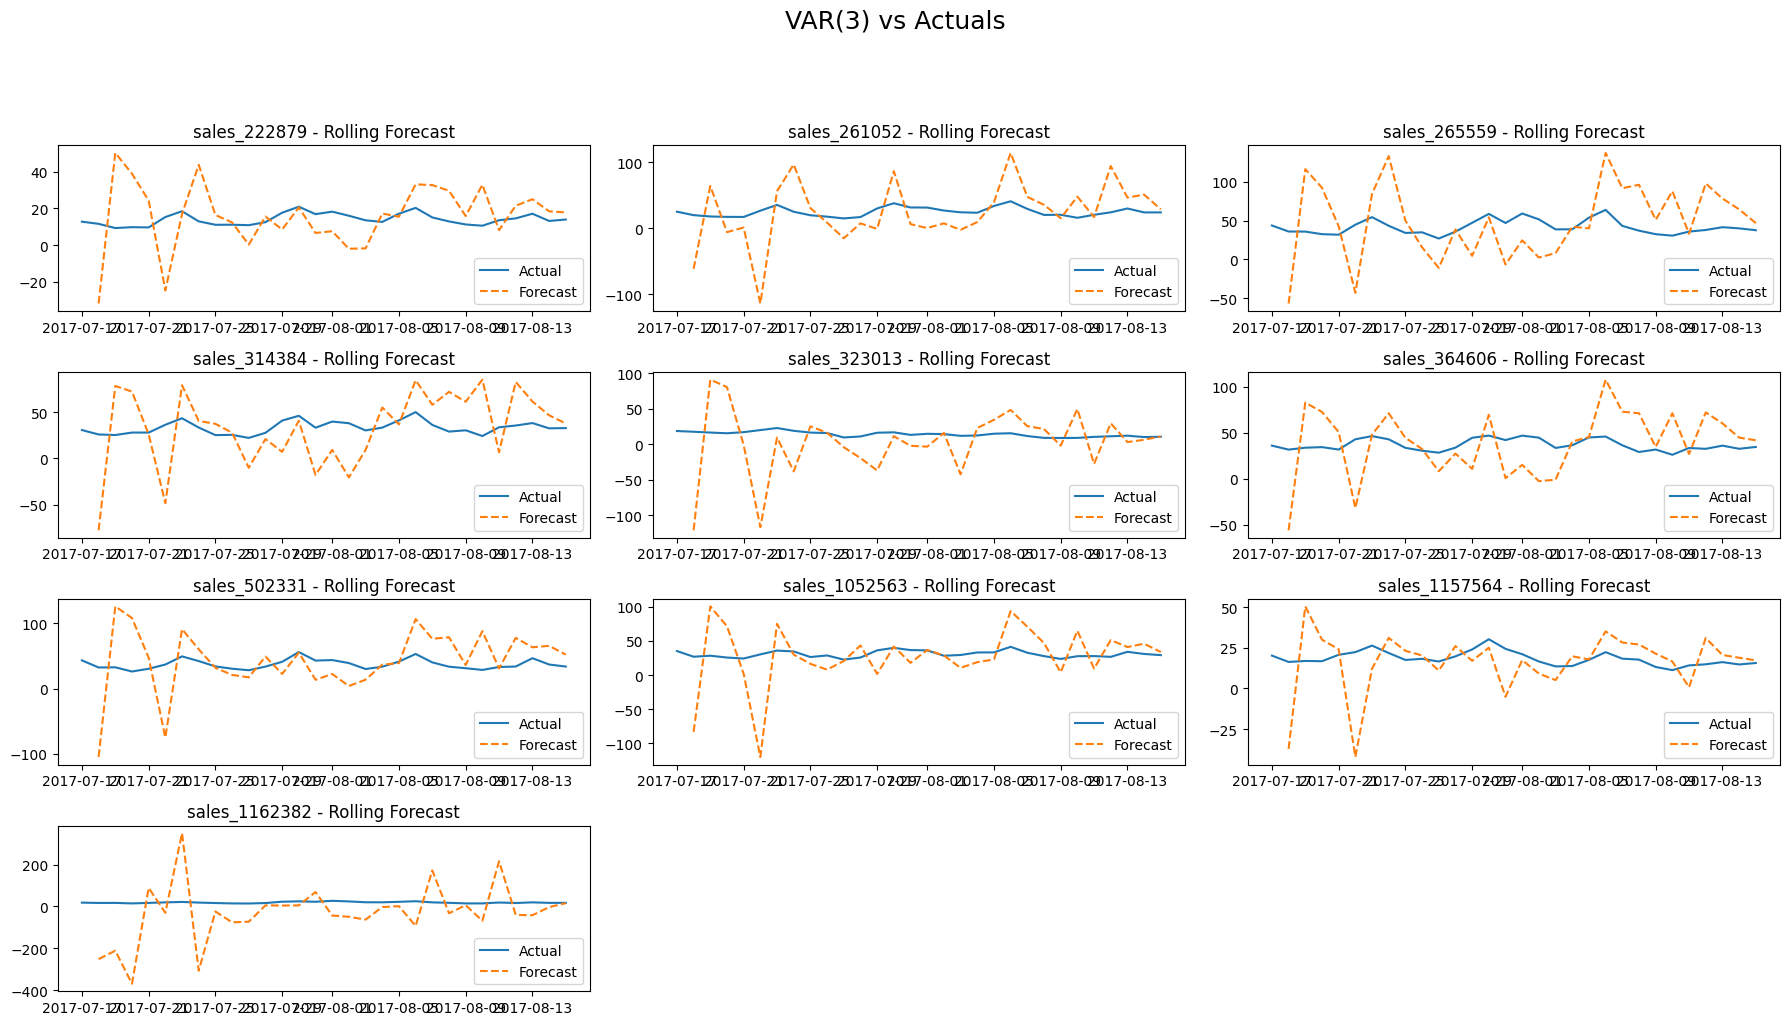

Evaluation metric results: VAR

Metrics for sales_222879:
MSE: 332.55975833862544
MAE: 13.570639965892477
RMSE: 18.236221054226817
MAPE: 109.02648325810307
MSPE: 332.55975833862544
sqrt MSPE: 18.236221054226817
R2: -32.13408487718608

Metrics for sales_261052:
MSE: 1910.8533058513276
MAE: 31.999795272039947
RMSE: 43.7133081092169
MAPE: 131.44456429429837
MSPE: 1910.8533058513276
sqrt MSPE: 43.7133081092169
R2: -39.608256462584336

Metrics for sales_265559:
MSE: 2333.417295731395
MAE: 39.70202413740832
RMSE: 48.30545823953433
MAPE: 98.81288769873284
MSPE: 2333.417295731395
sqrt MSPE: 48.30545823953433
R2: -26.182444159984076

Metrics for sales_314384:
MSE: 1597.6127441838369
MAE: 31.692841352863653
RMSE: 39.970148163145915
MAPE: 101.16097400998612
MSPE: 1597.6127441838369
sqrt MSPE: 39.970148163145915
R2: -33.065868232185196

Metrics for sales_323013:
MSE: 2231.6145552571516
MAE: 31.586696385448782
RMSE: 47.23996777366758
MAPE: 216.52529673135516
MSPE: 2231.6145552571516
sqrt MSPE: 47.2

In [32]:
import matplotlib.pyplot as plt
from sklearn import metrics

plt.figure(figsize=(18, 12))

plt.suptitle('VAR(3) vs Actuals', fontsize=18, y=1.02)

for i, col in enumerate(stock_cols):
    plt.subplot(5, 3, i + 1)
    plt.plot(test_data[col], label="Actual")
    plt.plot(fc_df[col], label="Forecast", linestyle='--')
    plt.title(f"{col} - Rolling Forecast")
    plt.legend()

plt.tight_layout(rect=[0, 0, 1, 0.97])  # leave room for suptitle
plt.show()

from sklearn import metrics

def mean_absolute_percentage_error(y_test, y_pred):
    y_true, y_pred = np.array(y_test), np.array(y_pred)
    return np.mean(np.abs((y_test - y_pred) / y_test)) * 100

def mean_squart_perdiction_error(y_test, y_pred):
    y_true, y_pred = np.array(y_test), np.array(y_pred)
    return np.mean(((y_test - y_pred))**2)

print('Evaluation metric results: VAR')
per_col_results = {}
for col in stock_cols:
    # Align indices explicitly and drop NaN values
    y_true = test_data[col].loc[fc_df.index]
    y_val_pred = fc_df[col]

    # Drop rows where predictions are NaN
    valid_mask = ~y_val_pred.isna()
    y_true = y_true[valid_mask]
    y_val_pred = y_val_pred[valid_mask]

    mse = metrics.mean_squared_error(y_true, y_val_pred)
    mae = metrics.mean_absolute_error(y_true, y_val_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, y_val_pred)
    mspe = mean_squart_perdiction_error(y_true, y_val_pred)
    r2 = metrics.r2_score(y_true, y_val_pred)

    per_col_results[col] = {
        'mse': mse, 'mae': mae, 'rmse': rmse, 'mape': mape, 'mspe': mspe, 'r2': r2
    }

    print(f"\nMetrics for {col}:")
    print(f'MSE: {mse}')
    print(f'MAE: {mae}')
    print(f'RMSE: {rmse}')
    print(f'MAPE: {mape}')
    print(f'MSPE: {mspe}')
    print(f'sqrt MSPE: {np.sqrt(mspe)}')
    print(f'R2: {r2}')
# Overall metrics across all series
# Drop rows with NaN in predictions
fc_df_clean = fc_df.dropna()
y_true_all = test_data.loc[fc_df_clean.index, stock_cols].values
y_pred_all = fc_df_clean[stock_cols].values
print(f'R2: {r2}')

# Overall metrics across all series (using cleaned data without NaN)
y_true_all = test_data.loc[fc_df_clean.index, stock_cols].values
y_pred_all = fc_df_clean[stock_cols].values

print(f"\nMetrics for VAR model (overall):")
print(f'MSE: {metrics.mean_squared_error(y_true_all, y_pred_all)}')
print(f'MAE: {metrics.mean_absolute_error(y_true_all, y_pred_all)}')
print(f'RMSE: {np.sqrt(metrics.mean_squared_error(y_true_all, y_pred_all))}')
print(f'MAPE: {mean_absolute_percentage_error(y_true_all, y_pred_all)}')
print(f'MSPE: {mean_squart_perdiction_error(y_true_all, y_pred_all)}')
print(f'sqrt MSPE: {np.sqrt(mean_squart_perdiction_error(y_true_all, y_pred_all))}')
print(f'R2: {metrics.r2_score(y_true_all, y_pred_all)}')

In [34]:
var_res = VAR(train_data).fit(best_p)

# In-sample predictions
train_pred = pd.DataFrame(var_res.fittedvalues, index=train_data.iloc[best_p:].index, columns=train_data.columns)   # DataFrame
train_true = train_data.iloc[best_p:]  # skip first p lags

print(train_pred.shape, train_true.shape)

from sklearn import metrics
import numpy as np

# Overall training metrics
train_mse = metrics.mean_squared_error(train_true, train_pred)
train_rmse = np.sqrt(train_mse)

print(f"Overall Train MSE: {train_mse}")
print(f"Overall Train RMSE: {train_rmse}")

for col in train_true.columns:
    mse = metrics.mean_squared_error(train_true[col], train_pred[col])
    mae = metrics.mean_absolute_error(train_true[col], train_pred[col])
    rmse = np.sqrt(mse)
    print(f"\nMetrics for {col}:")
    print(f"  MSE:  {mse}")
    print(f"  RMSE: {rmse:}")

(149, 21) (149, 21)
Overall Train MSE: 1.0443920615124402e-24
Overall Train RMSE: 1.021955019319559e-12

Metrics for sales_222879:
  MSE:  1.8034059149993198e-25
  RMSE: 4.2466526994791085e-13

Metrics for sales_261052:
  MSE:  9.445629034751745e-25
  RMSE: 9.7188626056508e-13

Metrics for sales_265559:
  MSE:  1.866625079701414e-24
  RMSE: 1.36624488277227e-12

Metrics for sales_314384:
  MSE:  7.435314540063609e-25
  RMSE: 8.622826995866036e-13

Metrics for sales_323013:
  MSE:  4.340273246892009e-24
  RMSE: 2.083332245920465e-12

Metrics for sales_364606:
  MSE:  1.0107669484228332e-24
  RMSE: 1.0053690608044557e-12

Metrics for sales_502331:
  MSE:  9.480917059620734e-25
  RMSE: 9.737000081966074e-13

Metrics for sales_1052563:
  MSE:  1.315339345959523e-24
  RMSE: 1.1468824464431929e-12

Metrics for sales_1157564:
  MSE:  6.541065418075644e-25
  RMSE: 8.087685341354251e-13

Metrics for sales_1162382:
  MSE:  9.867896175661472e-24
  RMSE: 3.141320769304127e-12

Metrics for promo_22